# 🔬 Test Whisper Large V3 — Speech-to-Text
**Model:** `openai/whisper-large-v3`  
**Task:** Automatic Speech Recognition (ASR) + Metrici pe dataset real  
**Dataset:** LJSpeech — `wavs/` + `metadata.csv` (pipe-separated: filename|normalized|original)  
**Metrici:** WER · CER · Levenshtein · BLEU · RTF · Latency  
**Doc:** [HF Whisper](https://huggingface.co/docs/transformers/main/en/model_doc/whisper)

---

## 1. Setup

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
    'jiwer', 'nltk', 'tqdm', '--quiet'], check=True)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import time, os, re, psutil, io
from pathlib import Path
from tqdm import tqdm
from jiwer import wer as jiwer_wer, cer as jiwer_cer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.float16 if torch.cuda.is_available() else torch.float32
print(f'Device: {device} | Dtype: {dtype}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB')


Device: cuda | Dtype: torch.float16
GPU: NVIDIA GeForce GTX 1650 | VRAM: 4.0 GB


## 2. Încărcare Model

In [2]:
MODEL_ID = 'openai/whisper-large-v3'
mem_before = psutil.Process().memory_info().rss / (1024**2)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForSpeechSeq2Seq.from_pretrained(MODEL_ID, torch_dtype=dtype, low_cpu_mem_usage=True)
model = model.to(device)
model.eval()

mem_after = psutil.Process().memory_info().rss / (1024**2)

total_params = sum(p.numel() for p in model.parameters())
param_mb = sum(p.numel()*p.element_size() for p in model.parameters()) / (1024**2)

print(f'\n✅ Model încărcat!')
print(f'   Parametri: {total_params:,}')
print(f'   Dimensiune: {param_mb:.0f} MB')
print(f'   RAM delta: {mem_after-mem_before:.0f} MB')
print(f'   Encoder layers: {model.config.encoder_layers}')
print(f'   Decoder layers: {model.config.decoder_layers}')
print(f'   d_model: {model.config.d_model}')
print(f'   Vocab size: {model.config.vocab_size}')


✅ Model încărcat!
   Parametri: 1,543,490,560
   Dimensiune: 2944 MB
   RAM delta: -234 MB
   Encoder layers: 32
   Decoder layers: 32
   d_model: 1280
   Vocab size: 51866


## 3. Configurare & Încărcare Dataset

Setează `AUDIO_DIR` și `METADATA_CSV` conform structurii de foldere.  
`MAX_SAMPLES = None` procesează tot dataset-ul.

In [ ]:
# ============================================================
# 🔧 CONFIGURARE — editează după structura ta de foldere
# ============================================================
AUDIO_DIR    = Path('dataset/dataset_audio/audio_files/wavs')
METADATA_CSV = Path('dataset/dataset_audio/audio_files/metadata.csv')
LANGUAGE     = 'en'       # limba audio ('en', 'ro', None = auto-detect)
MAX_SAMPLES  = 500         # None = tot dataset-ul
SAMPLE_RATE  = 16000      # Whisper necesită 16kHz

# ── Încărcare metadata ──────────────────────────────────────────
df_meta = pd.read_csv(METADATA_CSV, sep='|', header=None,
                       names=['filename', 'normalized', 'original'])
df_meta['filename']   = df_meta['filename'].str.strip()
df_meta['normalized'] = df_meta['normalized'].str.strip()
df_meta['original']   = df_meta['original'].str.strip()
df_meta['wav_path']   = df_meta['filename'].apply(
    lambda f: AUDIO_DIR / f'{f}.wav')
df_meta['exists'] = df_meta['wav_path'].apply(lambda p: p.exists())

missing = (~df_meta['exists']).sum()
if missing:
    print(f'⚠️  {missing} fișiere lipsă în {AUDIO_DIR} — vor fi sărite')

df_test = df_meta[df_meta['exists']].reset_index(drop=True)
if MAX_SAMPLES:
    df_test = df_test.head(MAX_SAMPLES)

print(f'✅ Fișiere disponibile: {df_meta["exists"].sum()}')
print(f'   Folosite în test:   {len(df_test)}')
df_test[['filename', 'normalized']].head(5)


⚠️  10 fișiere lipsă în dataset\dataset_audio\audio_files\wavs — vor fi sărite
✅ Fișiere disponibile: 13090
   Folosite în test:   50


,filename,normalized
0,LJ001-0011,it is of the first importance that the letter ...
1,LJ001-0012,"especially as no more time is occupied, or cos..."
2,LJ001-0013,than in the same operations with ugly ones.
3,LJ001-0014,And it was a matter of course that in the Midd...
4,LJ001-0015,the forms of printed letters should be beautif...


## 4. Funcții Metrici ASR

In [4]:
def normalize_text(text: str) -> str:
    """Lowercase, strip punctuation, collapse spaces."""
    text = text.lower()
    text = re.sub(r"[^\w\s']", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def levenshtein(s1: str, s2: str) -> int:
    """Character-level Levenshtein distance."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            dp[j] = prev[j-1] if s1[i-1] == s2[j-1] else 1 + min(prev[j-1], prev[j], dp[j-1])
    return dp[n]


def bleu_score(reference: str, hypothesis: str) -> float:
    """Sentence-level BLEU-4 cu Laplace smoothing."""
    ref_tok = reference.split()
    hyp_tok = hypothesis.split()
    if not hyp_tok:
        return 0.0
    return sentence_bleu([ref_tok], hyp_tok,
                          smoothing_function=SmoothingFunction().method1)


def compute_metrics(reference: str, hypothesis: str) -> dict:
    ref_n = normalize_text(reference)
    hyp_n = normalize_text(hypothesis)
    return {
        'wer' : jiwer_wer(ref_n, hyp_n),
        'cer' : jiwer_cer(ref_n, hyp_n),
        'lev' : levenshtein(ref_n, hyp_n),
        'bleu': bleu_score(ref_n, hyp_n),
    }


def audio_stats(audio):
    return {
        'duration_s': len(audio) / SAMPLE_RATE,
        'rms'       : float(np.sqrt(np.mean(audio**2))),
        'peak'      : float(np.max(np.abs(audio))),
        'mean'      : float(np.mean(audio)),
        'std'       : float(np.std(audio)),
        'silence_%' : float(np.sum(np.abs(audio) < 0.01) / len(audio) * 100),
    }


print('✅ Metrici definite: WER, CER, Levenshtein, BLEU, audio stats')


✅ Metrici definite: WER, CER, Levenshtein, BLEU, audio stats


## 5. Transcriere + Metrici

Se parcurg toate fișierele din `df_test`, se transcrie cu Whisper și se calculează  
WER, CER, Levenshtein, BLEU, RTF și latency per fișier.

In [5]:
import soundfile as sf
import librosa

results = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Transcriere'):
    wav_path  = str(row['wav_path'])
    reference = row['normalized']

    # ── Încărcare și pre-procesare audio ──
    audio_data, orig_sr = sf.read(wav_path, dtype='float32')
    if orig_sr != SAMPLE_RATE:
        audio_data = librosa.resample(audio_data, orig_sr=orig_sr, target_sr=SAMPLE_RATE)
    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1)  # stereo → mono

    a_stats = audio_stats(audio_data)

    inputs = processor(audio_data, sampling_rate=SAMPLE_RATE, return_tensors='pt')
    input_features = inputs.input_features.to(device, dtype=dtype)

    # ── Inferență ──
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    with torch.no_grad():
        generated_ids = model.generate(
            input_features,
            max_new_tokens=256,
            language=LANGUAGE,
        )
    t_inf = time.perf_counter() - t0

    hypothesis  = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    gpu_peak_mb = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0.0

    # ── Metrici ──
    m = compute_metrics(reference, hypothesis)

    results.append({
        'filename'    : row['filename'],
        'reference'   : reference,
        'hypothesis'  : hypothesis,
        'audio_dur_s' : a_stats['duration_s'],
        'latency_s'   : t_inf,
        'rtf'         : t_inf / a_stats['duration_s'],
        'gpu_peak_mb' : gpu_peak_mb,
        'num_tokens'  : len(generated_ids[0]),
        **m,
        'audio_stats' : a_stats,
    })

df_results = pd.DataFrame(results)
print(f'\n\u2705 Transcriere finalizată! ({len(df_results)} fișiere)')


Transcriere: 100%|██████████| 50/50 [08:02<00:00,  9.64s/it]


✅ Transcriere finalizată! (50 fișiere)


## 6. Rezultate Transcriere

In [6]:
display_cols = ['filename','wer','cer','bleu','lev','rtf','latency_s','audio_dur_s','num_tokens']
df_disp = df_results[display_cols].copy()
for col in ['wer','cer','bleu']:
    df_disp[col] = df_disp[col].apply(lambda x: f'{x:.3f}')
df_disp['rtf']        = df_disp['rtf'].apply(lambda x: f'{x:.3f}')
df_disp['latency_s']  = df_disp['latency_s'].apply(lambda x: f'{x:.2f}')
df_disp['audio_dur_s']= df_disp['audio_dur_s'].apply(lambda x: f'{x:.2f}')
display(df_disp)


,filename,wer,cer,bleu,lev,rtf,latency_s,audio_dur_s,num_tokens
0,LJ001-0011,0.000,0.000,1.000,0,2.275,10.27,4.51,16
1,LJ001-0012,0.000,0.000,1.000,0,1.110,9.14,8.24,20
2,LJ001-0013,0.000,0.000,1.000,0,3.241,8.38,2.58,9
3,LJ001-0014,0.032,0.006,0.913,1,1.011,10.05,9.95,32
4,LJ001-0015,0.000,0.000,1.000,0,1.080,9.98,9.24,31
5,LJ001-0016,0.000,0.000,1.000,0,1.703,8.97,5.27,17
6,LJ001-0017,0.000,0.000,1.000,0,1.360,9.54,7.02,25
7,LJ001-0018,0.000,0.000,1.000,0,1.285,9.61,7.48,26
8,LJ001-0019,0.111,0.009,0.781,1,1.442,9.25,6.42,21
9,LJ001-0020,0.000,0.000,1.000,0,1.888,8.83,4.67,15


## 7. Metrici Agregate (WER · CER · BLEU · Levenshtein)

In [7]:
print('='*70)
print('METRICI AGREGATE')
print('='*70)
print(f'  Mean WER        : {df_results["wer"].mean():.4f}  (lower = better)')
print(f'  Mean CER        : {df_results["cer"].mean():.4f}  (lower = better)')
print(f'  Mean BLEU       : {df_results["bleu"].mean():.4f}  (higher = better)')
print(f'  Mean Levenshtein: {df_results["lev"].mean():.1f}    (lower = better)')
print(f'  Mean RTF        : {df_results["rtf"].mean():.3f}   (< 1.0 = faster-than-realtime)')
print(f'  Mean Latency    : {df_results["latency_s"].mean():.2f}s')
print()

agg = df_results[['wer','cer','bleu','lev','rtf','latency_s','audio_dur_s']].agg(['mean','median','std','min','max'])
display(agg.round(4).T)

# Cele mai bune / slabe 5 după WER
def show_samples(df_sub, title):
    print(f'\n{"="*70}')
    print(f'  {title}')
    print(f'{"="*70}')
    for _, r in df_sub.iterrows():
        print(f'  📁 {r["filename"]}  WER={r["wer"]:.3f}  CER={r["cer"]:.3f}  BLEU={r["bleu"]:.3f}')
        print(f'     REF : {r["reference"][:110]}')
        print(f'     HYP : {r["hypothesis"][:110]}')
        print()

show_samples(df_results.nsmallest(5, 'wer'), 'TOP 5 — WER cel mai MIC (cel mai bun)')
show_samples(df_results.nlargest(5,  'wer'), 'TOP 5 — WER cel mai MARE (cel mai slab)')


METRICI AGREGATE
  Mean WER        : 0.0395  (lower = better)
  Mean CER        : 0.0166  (lower = better)
  Mean BLEU       : 0.8984  (higher = better)
  Mean Levenshtein: 1.7    (lower = better)
  Mean RTF        : 1.518   (< 1.0 = faster-than-realtime)
  Mean Latency    : 9.31s



,mean,median,std,min,max
wer,0.0395,0.0000,0.0607,0.0000,0.2778
cer,0.0166,0.0000,0.0362,0.0000,0.1569
bleu,0.8984,1.0000,0.1506,0.3162,1.0000
lev,1.7400,0.0000,3.9321,0.0000,16.0000
rtf,1.5180,1.3678,0.4577,1.0106,3.2409
latency_s,9.3104,9.2960,0.4638,8.1573,10.2652
audio_dur_s,6.6374,6.8977,1.8346,2.5846,9.9453



  TOP 5 — WER cel mai MIC (cel mai bun)
  📁 LJ001-0011  WER=0.000  CER=0.000  BLEU=1.000
     REF : it is of the first importance that the letter used should be fine in form;
     HYP : It is of the first importance that the letter used should be fine in form,

  📁 LJ001-0012  WER=0.000  CER=0.000  BLEU=1.000
     REF : especially as no more time is occupied, or cost incurred, in casting, setting, or printing beautiful letters
     HYP : especially as no more time is occupied or cost incurred in casting, setting, or printing beautiful letters

  📁 LJ001-0013  WER=0.000  CER=0.000  BLEU=1.000
     REF : than in the same operations with ugly ones.
     HYP : than in the same operations with ugly ones.

  📁 LJ001-0015  WER=0.000  CER=0.000  BLEU=1.000
     REF : the forms of printed letters should be beautiful, and that their arrangement on the page should be reasonable 
     HYP : the forms of printed letters should be beautiful, and that their arrangement on the page should be reasonab

## 8. Performanță

In [8]:
print('='*95)
print('PERFORMANȚĂ')
print('='*95)
print(f'{"Fișier":<20} {"Audio (s)":>10} {"Inf (s)":>10} {"RTF":>8} {"Tokens":>8} {"GPU Peak":>10}')
print(f'{"─"*70}')
for _, r in df_results.iterrows():
    print(f'{r["filename"]:<20} {r["audio_dur_s"]:>10.1f} {r["latency_s"]:>10.3f} '
          f'{r["rtf"]:>8.3f} {r["num_tokens"]:>8} {r["gpu_peak_mb"]:>8.0f} MB')
print(f'{"─"*70}')
print(f'{"MEDIE":<20} {df_results["audio_dur_s"].mean():>10.1f} {df_results["latency_s"].mean():>10.3f} '
      f'{df_results["rtf"].mean():>8.3f}')
print(f'\nRTF < 1.0 = mai rapid decât real-time')


PERFORMANȚĂ
Fișier                Audio (s)    Inf (s)      RTF   Tokens   GPU Peak
──────────────────────────────────────────────────────────────────────
LJ001-0011                  4.5     10.265    2.275       16     3199 MB
LJ001-0012                  8.2      9.143    1.110       20     3200 MB
LJ001-0013                  2.6      8.376    3.241        9     3198 MB
LJ001-0014                  9.9     10.051    1.011       32     3202 MB
LJ001-0015                  9.2      9.978    1.080       31     3202 MB
LJ001-0016                  5.3      8.967    1.703       17     3200 MB
LJ001-0017                  7.0      9.543    1.360       25     3201 MB
LJ001-0018                  7.5      9.615    1.285       26     3201 MB
LJ001-0019                  6.4      9.250    1.442       21     3200 MB
LJ001-0020                  4.7      8.826    1.888       15     3199 MB
LJ001-0021                  8.6      9.692    1.126       27     3201 MB
LJ001-0022                  7.1      9.546

## 9. Statistici Audio

In [9]:
print('='*90)
print('STATISTICI AUDIO')
print('='*90)
print(f'{"Fișier":<20} {"Durată":>8} {"RMS":>8} {"Peak":>8} {"StdDev":>8} {"Silence%":>10}')
print(f'{"─"*70}')
for _, r in df_results.iterrows():
    a = r['audio_stats']
    print(f'{r["filename"]:<20} {a["duration_s"]:>7.1f}s {a["rms"]:>8.4f} '
          f'{a["peak"]:>8.4f} {a["std"]:>8.4f} {a["silence_%"]:>9.1f}%')


STATISTICI AUDIO
Fișier                 Durată      RMS     Peak   StdDev   Silence%
──────────────────────────────────────────────────────────────────────
LJ001-0011               4.5s   0.0946   0.7845   0.0946      34.8%
LJ001-0012               8.2s   0.0913   0.9265   0.0913      36.4%
LJ001-0013               2.6s   0.0986   0.8900   0.0986      24.8%
LJ001-0014               9.9s   0.0889   0.7714   0.0889      38.0%
LJ001-0015               9.2s   0.0911   0.7046   0.0911      36.4%
LJ001-0016               5.3s   0.1002   0.7330   0.1002      37.7%
LJ001-0017               7.0s   0.1081   0.9691   0.1081      34.9%
LJ001-0018               7.5s   0.0942   0.7377   0.0942      37.4%
LJ001-0019               6.4s   0.0857   0.6189   0.0857      34.1%
LJ001-0020               4.7s   0.0930   0.7973   0.0930      32.6%
LJ001-0021               8.6s   0.0946   0.6890   0.0946      36.1%
LJ001-0022               7.1s   0.0921   0.6592   0.0921      39.4%
LJ001-0023               8.4

## 10. Grafice

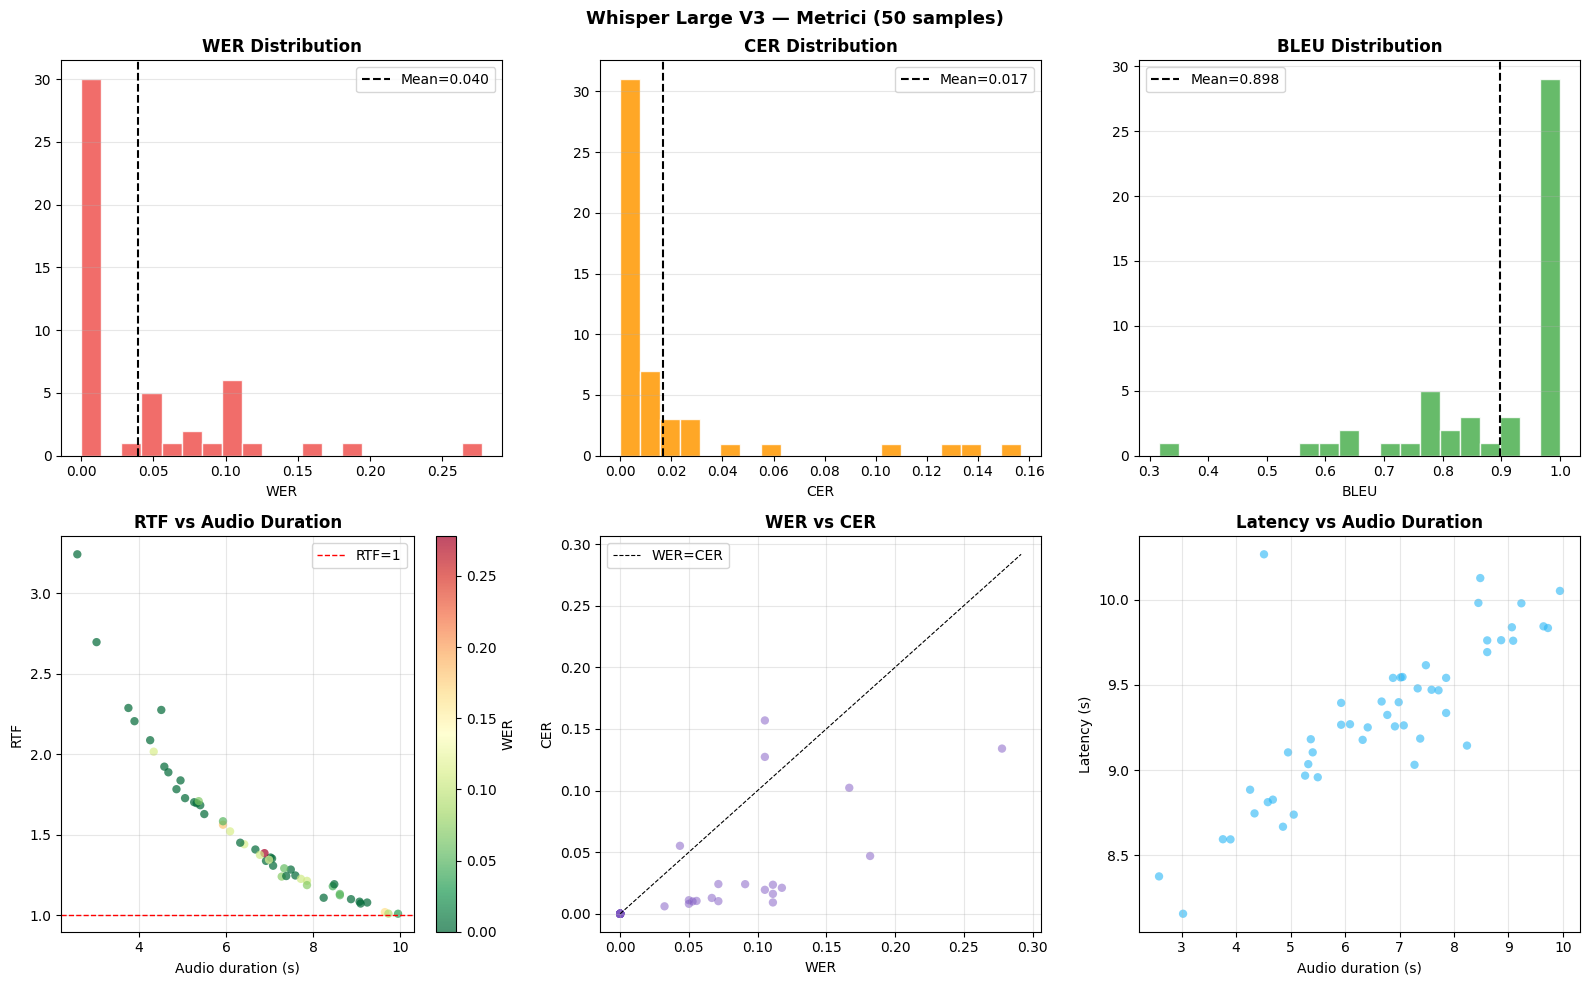

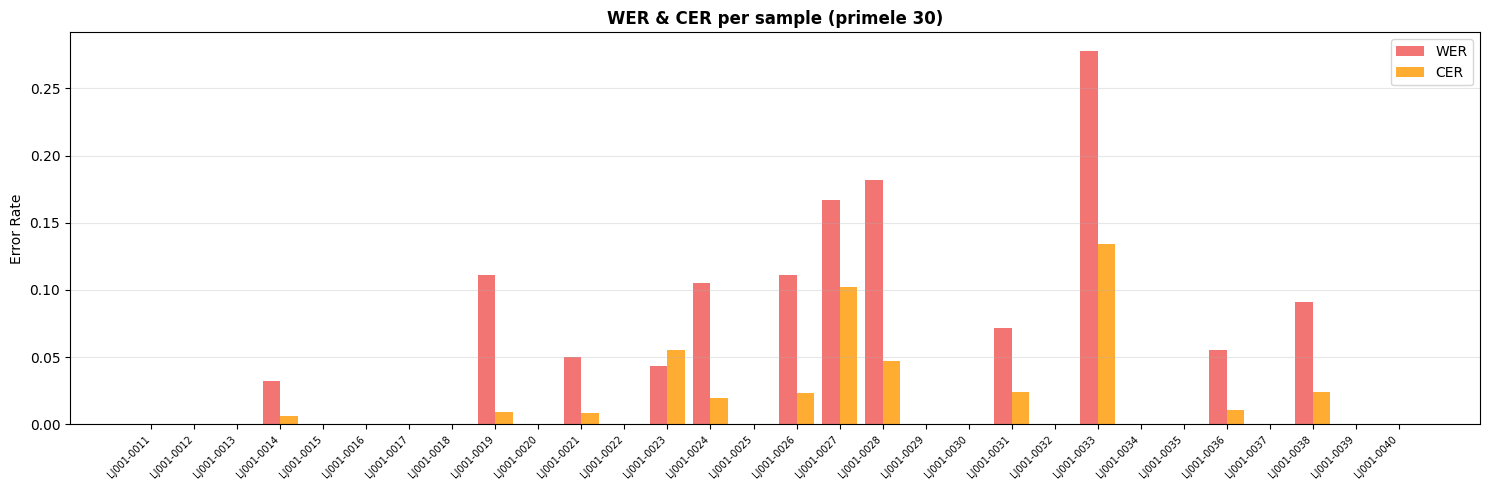

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ① WER histogram
ax = axes[0, 0]
ax.hist(df_results['wer'], bins=20, color='#EF5350', edgecolor='white', alpha=0.85)
ax.axvline(df_results['wer'].mean(), color='black', linestyle='--',
           label=f"Mean={df_results['wer'].mean():.3f}")
ax.set_title('WER Distribution', fontweight='bold'); ax.set_xlabel('WER'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# ② CER histogram
ax = axes[0, 1]
ax.hist(df_results['cer'], bins=20, color='#FF9800', edgecolor='white', alpha=0.85)
ax.axvline(df_results['cer'].mean(), color='black', linestyle='--',
           label=f"Mean={df_results['cer'].mean():.3f}")
ax.set_title('CER Distribution', fontweight='bold'); ax.set_xlabel('CER'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# ③ BLEU histogram
ax = axes[0, 2]
ax.hist(df_results['bleu'], bins=20, color='#4CAF50', edgecolor='white', alpha=0.85)
ax.axvline(df_results['bleu'].mean(), color='black', linestyle='--',
           label=f"Mean={df_results['bleu'].mean():.3f}")
ax.set_title('BLEU Distribution', fontweight='bold'); ax.set_xlabel('BLEU'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# ④ RTF scatter
ax = axes[1, 0]
sc = ax.scatter(df_results['audio_dur_s'], df_results['rtf'],
                c=df_results['wer'], cmap='RdYlGn_r', alpha=0.7, edgecolors='none')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='RTF=1')
plt.colorbar(sc, ax=ax, label='WER')
ax.set_title('RTF vs Audio Duration', fontweight='bold')
ax.set_xlabel('Audio duration (s)'); ax.set_ylabel('RTF'); ax.legend(); ax.grid(alpha=0.3)

# ⑤ WER vs CER
ax = axes[1, 1]
ax.scatter(df_results['wer'], df_results['cer'], alpha=0.5, color='#7E57C2', edgecolors='none')
lim = max(df_results['wer'].max(), df_results['cer'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='WER=CER')
ax.set_title('WER vs CER', fontweight='bold')
ax.set_xlabel('WER'); ax.set_ylabel('CER'); ax.legend(); ax.grid(alpha=0.3)

# ⑥ Latency vs Audio duration
ax = axes[1, 2]
ax.scatter(df_results['audio_dur_s'], df_results['latency_s'],
           alpha=0.6, color='#29B6F6', edgecolors='none')
ax.set_title('Latency vs Audio Duration', fontweight='bold')
ax.set_xlabel('Audio duration (s)'); ax.set_ylabel('Latency (s)'); ax.grid(alpha=0.3)

plt.suptitle(f'Whisper Large V3 — Metrici ({len(df_results)} samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── WER/CER per-sample bar chart (primele 30) ──
n_bar = min(30, len(df_results))
df_bar = df_results.head(n_bar)
x = np.arange(n_bar); w = 0.4
fig2, ax2 = plt.subplots(figsize=(max(12, n_bar // 2), 5))
ax2.bar(x - w/2, df_bar['wer'], w, label='WER', color='#EF5350', alpha=0.8)
ax2.bar(x + w/2, df_bar['cer'], w, label='CER', color='#FF9800', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(df_bar['filename'].str[-10:], rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('Error Rate')
ax2.set_title(f'WER & CER per sample (primele {n_bar})', fontweight='bold')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Sumar

In [11]:
print('█'*70)
print('  SUMAR — Whisper Large V3')
print('█'*70)
print(f'  Model:      {MODEL_ID}')
print(f'  Parametri:  {total_params:,}')
print(f'  Size:       {param_mb:.0f} MB')
print(f'  Device:     {device}')
print(f'  Samples:    {len(df_results)}')
print(f'  Mean WER  : {df_results["wer"].mean():.4f}')
print(f'  Mean CER  : {df_results["cer"].mean():.4f}')
print(f'  Mean BLEU : {df_results["bleu"].mean():.4f}')
print(f'  Mean RTF  : {df_results["rtf"].mean():.3f}x')
print(f'  Total time: {df_results["latency_s"].sum():.1f}s')
print('█'*70)


██████████████████████████████████████████████████████████████████████
  SUMAR — Whisper Large V3
██████████████████████████████████████████████████████████████████████
  Model:      openai/whisper-large-v3
  Parametri:  1,543,490,560
  Size:       2944 MB
  Device:     cuda
  Samples:    50
  Mean WER  : 0.0395
  Mean CER  : 0.0166
  Mean BLEU : 0.8984
  Mean RTF  : 1.518x
  Total time: 465.5s
██████████████████████████████████████████████████████████████████████


## 12. Export Rezultate

In [12]:
OUT = Path('output_whisper')
OUT.mkdir(exist_ok=True)

# CSV complet
csv_path = OUT / 'results.csv'
df_results.drop(columns=['audio_stats']).to_csv(csv_path, index=False)
print(f'✅ CSV salvat: {csv_path.resolve()}')

# Transcrieri text
txt_path = OUT / 'transcriptions.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    for _, r in df_results.iterrows():
        f.write(f'{r["filename"]}:\n')
        f.write(f'  REF : {r["reference"]}\n')
        f.write(f'  HYP : {r["hypothesis"]}\n')
        f.write(f'  WER={r["wer"]:.3f}  CER={r["cer"]:.3f}  BLEU={r["bleu"]:.3f}  RTF={r["rtf"]:.3f}\n\n')
print(f'✅ Transcrieri salvate: {txt_path.resolve()}')


✅ CSV salvat: C:\Users\redis\Desktop\Projects\Licenta-App\test_modele_ai\output_whisper\results.csv
✅ Transcrieri salvate: C:\Users\redis\Desktop\Projects\Licenta-App\test_modele_ai\output_whisper\transcriptions.txt


---
## 📝 Note
- **Dataset:** CSV pipe-separated `filename|normalized|original` — coloana `normalized` e folosită ca referință
- **WER/CER:** calculat cu `jiwer` după normalizare (lowercase, fără punctuație)
- **BLEU:** sentence-level BLEU-4 cu Laplace smoothing (`nltk`)
- **Levenshtein:** distanță caracter-la-caracter între referință și ipoteză normalizate
- **RTF:** Real-Time Factor — < 1.0 înseamnă mai rapid decât real-time
- **Limbă:** setează `LANGUAGE='ro'` pentru română sau `None` pentru auto-detect
- **VRAM:** ~6-10 GB pt large-v3; folosește `large-v2` sau `medium` dacă nu ai suficientă memorie
- **MAX_SAMPLES:** pune `None` pt a rula pe tot dataset-ul (13 100 fișiere)
